In [ ]:
#! pip uninstall torch torchvision torchaudio -y
#! pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [2]:
import torch
print(torch.cuda.is_available())  # ¿True?
print(torch.version.cuda)         # ¿"11.8", "12.1", etc?
print(torch.cuda.get_device_name(0))  # ¿Detecta tu GPU?


True
12.8
NVIDIA GeForce RTX 4070 SUPER


In [ ]:
#! pip install opencv-python pandas

  Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached pandas-2.2.3-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl (39.5 MB)
Using cached pandas-2.2.3-cp311-cp311-win_amd64.whl (11.6 MB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import os
import cv2
import pandas as pd

ruta_base = "/home/jeff/Trabajo/Cedulas/imagenes_cedula_peq"  # Cambia esto por la ruta a tu carpeta raíz
data = []  # Lista para guardar (ruta, etiqueta)

for carpeta_actual, subcarpetas, archivos in os.walk(ruta_base):
    for archivo in archivos:
        if archivo.lower().endswith((".jpg", ".png")):
            ruta_completa = os.path.join(carpeta_actual, archivo)
            label = os.path.basename(carpeta_actual)
            data.append({"Path": ruta_completa, "Label": label})

# Crear el DataFrame
df = pd.DataFrame(data)
df['Label_decode'], uniques = pd.factorize(df["Label"])
stratiffy=[i for i in uniques]
print(df.head())

                                                Path            Label  \
0  /home/jeff/Trabajo/Cedulas/imagenes_cedula_peq...  Cedula_Amarilla   
1  /home/jeff/Trabajo/Cedulas/imagenes_cedula_peq...  Cedula_Amarilla   
2  /home/jeff/Trabajo/Cedulas/imagenes_cedula_peq...  Cedula_Amarilla   
3  /home/jeff/Trabajo/Cedulas/imagenes_cedula_peq...  Cedula_Amarilla   
4  /home/jeff/Trabajo/Cedulas/imagenes_cedula_peq...  Cedula_Amarilla   

   Label_decode  
0             0  
1             0  
2             0  
3             0  
4             0  


/tmp/ipykernel_8405/3432273608.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Label', y='Cantidad', data=conteo, palette='viridis')


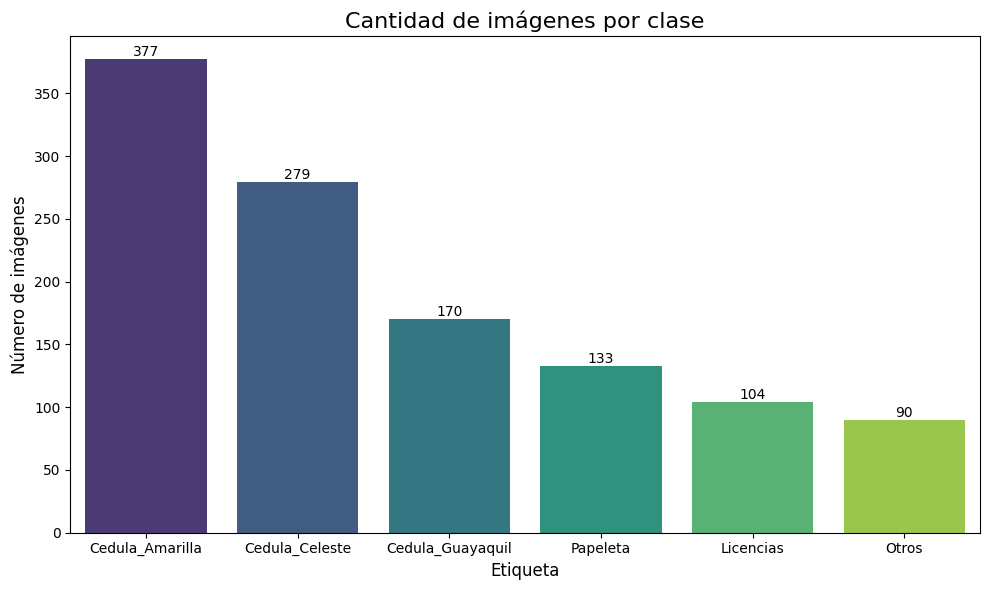

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Conteo de imágenes por clase
conteo = df['Label'].value_counts().reset_index()
conteo.columns = ['Label', 'Cantidad']

# Crear figura
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Label', y='Cantidad', data=conteo, palette='viridis')

# Mostrar los valores encima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',               # texto
                (p.get_x() + p.get_width() / 2., height),  # posición
                ha='center', va='bottom', fontsize=10)

# Personalización del gráfico
plt.title('Cantidad de imágenes por clase', fontsize=16)
plt.xlabel('Etiqueta', fontsize=12)
plt.ylabel('Número de imágenes', fontsize=12)
plt.tight_layout()
plt.show()


In [105]:
import torch
from torchvision import models, transforms
import torch.nn as nn
import cv2
from tqdm import tqdm

# 1. Modelo MobileNetV2 con avgpool
mobilenet = models.mobilenet_v2(weights="IMAGENET1K_V2")
feature_extractor = nn.Sequential(
    mobilenet.features,
    nn.AdaptiveAvgPool2d((1, 1))  # ↓ reduce a (batch_size, 1280, 1, 1)
)
feature_extractor.eval()

# 2. Preprocesamiento estándar (IMAGENET compatible)
preprocess = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],  # mejor usar valores de imagenet
                             std=[0.229, 0.224, 0.225]),
    ]
)

# 3. Extraer vectores
features_list = []
labels_list = []

def extract_feature_vector(image_path: str) -> torch.Tensor:
    """
    Extrae un vector de características de tamaño (1280,) de una imagen usando MobileNetV2.

    Args:
        image_path (str): Ruta al archivo de imagen.

    Returns:
        np.ndarray: Vector de características de tamaño (1280,) o None si hay error.
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"[WARNING] No se pudo cargar la imagen: {image_path}")
        return None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    input_tensor = preprocess(img_rgb).unsqueeze(0)

    with torch.no_grad():
        features = feature_extractor(input_tensor)
        vector = features.view(-1).numpy()  # → shape: (1280,)
    
    return vector

for i, row in df.iterrows():
    image_pros=extract_feature_vector(row["Path"])
    features_list.append(image_pros)
    labels_list.append(row["Label"])



In [106]:
print(features_list[0].shape)

(1280,)


In [107]:
from sklearn.manifold import TSNE
import numpy as np
# Convertir a array
X = np.array(features_list)
y = np.array(labels_list)

# Ejecutar t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=42)
X_embedded = tsne.fit_transform(X)


/home/jeff/anaconda3/envs/trabajo/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


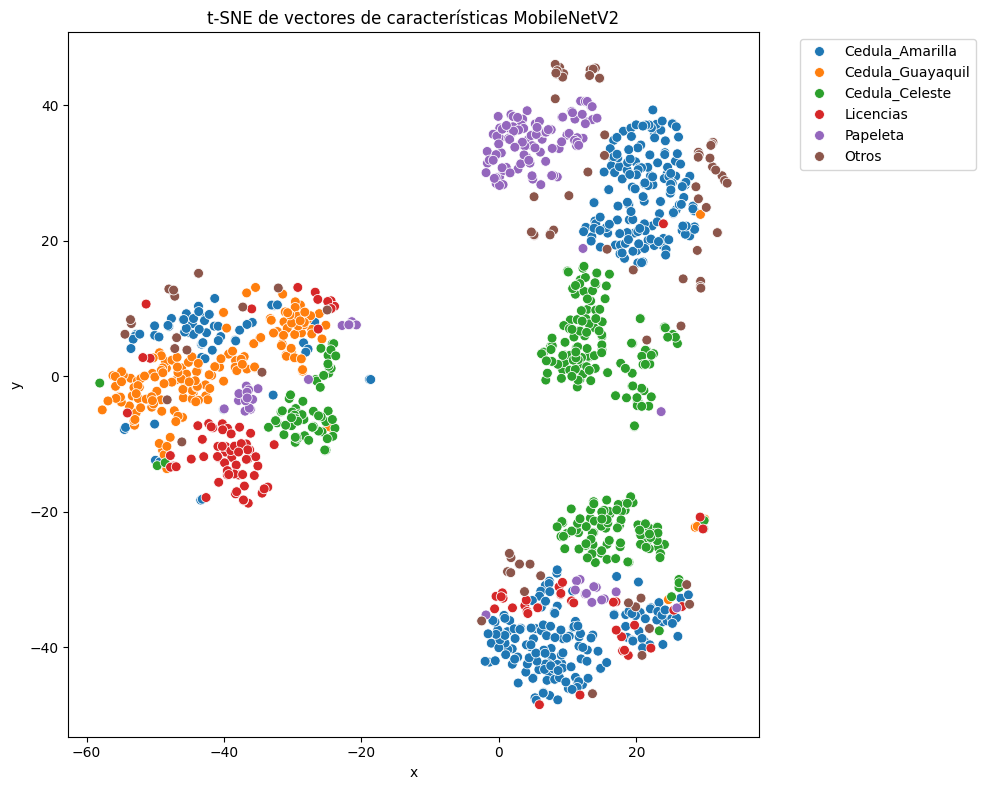

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear DataFrame para graficar
tsne_df = pd.DataFrame({
    "x": X_embedded[:, 0],
    "y": X_embedded[:, 1],
    "Label": y
})

plt.figure(figsize=(10, 8))
sns.scatterplot(data=tsne_df, x="x", y="y", hue="Label", palette="tab10", s=50)
plt.title("t-SNE de vectores de características MobileNetV2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
    shuffle=True,
)

print(X_train.shape)

(807, 1280)


In [ ]:
#%matplotlib inline
#
#from ultralytics import YOLO
#import cv2
#import matplotlib.pyplot as plt
#import random
##from paddleocr import PaddleOCR
#import numpy as np
##import easyocr
#from PIL import Image
##ocr = PaddleOCR(use_angle_cls=True, lang='es')
#fig,axes=plt.subplots(10,4, figsize=(40, 60))
#axes = axes.flatten()
#fig_2,axes_2=plt.subplots(10,4, figsize=(40, 60))
#axes_2 = axes_2.flatten()
#random.seed(42)  # Fijar la semilla para reproducibilidad
#imges_muestra = random.sample(images,40)  # Selecciona una imagen aleatoria de la lista
## Cargar el modelo YOLOv5 o YOLOv8 entrenado
#model = YOLO("E:/Users/Documents/Trabajo/Cedulas/best copy.pt")
## Leer la imagen
#
## Realizar la inferencia
#conf_threshold = 0.7  # Ajusta este valor a tu preferencia
#roi_array=[]
#for i, image in enumerate(imges_muestra):
#    results = model(image, device='cpu')  # o 'cpu' si no hay GPU
#
#    # Filtrar cajas por confianza
#    filtered_boxes = results[0].boxes  # Objeto Boxes de Ultralytics
#    #print(filtered_boxes)
#    mask = filtered_boxes.conf > conf_threshold
#    #print("###########",filtered_boxes.xyxy[0].tolist())
#
#    # Si hay detecciones que pasan el filtro
#    if mask.any():
#        filtered_boxes = filtered_boxes[mask]
#        results[0].boxes = filtered_boxes  # Sobrescribimos con solo las que pasan el umbral
#
#        # Dibujar y mostrar
#        annotated_image = results[0].plot()
#    else:
#        # Si no hay detecciones válidas, mostrar la imagen original
#        annotated_image = image.copy()
#
#    annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
#    axes[i].imshow(annotated_image_rgb)
#    axes[i].axis('off')
#    box=[int(cd) for cd in filtered_boxes.xyxy.tolist()[0]]
#    xmin,ymin,xmax,ymax=box
#    roi_orin = image[ymin:ymax, xmin:xmax]
#    roi = cv2.cvtColor(roi_orin, cv2.COLOR_BGR2GRAY)
#    roi = Image.fromarray(roi_orin)
#    # Convertir a RGB (Tesseract espera imágenes RGB, no BGR)
#    axes_2[i].imshow(roi)
#    roi_array.append(roi)
#
#
#

In [ ]:

import torchvision as tv
from PIL import Image
import torch.nn as nn
import torch
from torchvision import models

transform = tv.transforms.Compose([
            tv.transforms.Resize((224, 224)),
            tv.transforms.ToTensor(),
            tv.transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
        ])

class MobileNetV2Custom(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.mobilenet_v2(weights="IMAGENET1K_V2")
        # Congelar capas convolucionales
        for param in self.model.features.parameters():
            param.requires_grad = False

    def forward(self, x):
        # Extraer características
        features = self.model.features(x)
        features = nn.functional.adaptive_avg_pool2d(features, (1, 1))
        features = torch.flatten(features, 1)
        return features

    def extract_features(self, image_tensor: torch.Tensor) -> torch.Tensor:
        """Método explícito para inferencia"""
        self.eval()
        with torch.no_grad():
            return self(image_tensor)
